PARTE 1

In [6]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import drive
drive.mount('/content/drive')

csv_file_path = '/content/drive/MyDrive/Jogos.csv'  # Caminho do arquivo na pasta do Drive
drive_df = pd.read_csv(csv_file_path) # Lê o dataset
display(drive_df.head()) #Exibe as 5 primeiras linhas da tabela

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Name,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,82.53,76.0,51.0,E
1,Super Mario Bros.,NES,1985.0,Platform,40.24,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,35.52,82.0,73.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,32.77,80.0,73.0,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,31.37,NaN,NaN,NaN


In [8]:
l, c = drive_df.shape
print(f'O dataset possui {l} linhas e {c} colunas.')

O dataset possui 200 linhas e 8 colunas.


In [9]:
print(drive_df.dtypes) #Object = string; float64 = decimal

Name                object
Platform            object
Year_of_Release    float64
Genre               object
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
Rating              object
dtype: object


In [10]:
print(drive_df.info)

<bound method DataFrame.info of                                    Name Platform  Year_of_Release  \
0                            Wii Sports      Wii           2006.0   
1                     Super Mario Bros.      NES           1985.0   
2                        Mario Kart Wii      Wii           2008.0   
3                     Wii Sports Resort      Wii           2009.0   
4              Pokemon Red/Pokemon Blue       GB           1996.0   
..                                  ...      ...              ...   
195          Microsoft Flight Simulator       PC           1996.0   
196                      Guitar Hero II      PS2           2006.0   
197                           Fable III     X360           2010.0   
198  Mario & Sonic at the Olympic Games       DS           2008.0   
199                     Resident Evil 5      PS3           2009.0   

            Genre  Global_Sales  Critic_Score  Critic_Count Rating  
0          Sports         82.53          76.0          51.0      E  
1

In [11]:
print(drive_df.describe()) #Mostra de todas as colunas numéricas: contagem, média, desvio padrão, mínimo, quartis (25%, 50%, 75%) e máximo

       Year_of_Release  Global_Sales  Critic_Score  Critic_Count
count       199.000000     200.00000    140.000000    140.000000
mean       2005.231156      10.28490     86.421429     56.235714
std           7.361299       8.22195      8.948347     25.925630
min        1982.000000       5.09000     49.000000      8.000000
25%        2001.000000       5.85750     83.000000     37.000000
50%        2007.000000       7.38500     88.000000     58.000000
75%        2011.000000      11.22250     93.250000     77.000000
max        2016.000000      82.53000     98.000000    113.000000


PARTE 2

In [12]:
drive_df.isnull().sum()

,0
Name,0
Platform,0
Year_of_Release,1
Genre,0
Global_Sales,0
Critic_Score,60
Critic_Count,60
Rating,59


In [13]:
drive_df = drive_df.dropna() # Remove linhas com os valores nulos
drive_df = drive_df.astype({'Year_of_Release': int, 'Critic_Score': int, 'Critic_Count': int}) # Transforma as colunas Ano de lançamento, Pontuação crítica e número de críticos em inteiros
#drive_df = drive_df.drop('Rating', axis=1) axis=1 para apagar 1 colunas

#print(drive_df.duplicated()) não tem duplicatas
l,c = drive_df.shape

print(f'O dataset possui {l} linhas e {c} colunas')
print(drive_df.info())


O dataset possui 139 linhas e 8 colunas
<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             139 non-null    object 
 1   Platform         139 non-null    object 
 2   Year_of_Release  139 non-null    int64  
 3   Genre            139 non-null    object 
 4   Global_Sales     139 non-null    float64
 5   Critic_Score     139 non-null    int64  
 6   Critic_Count     139 non-null    int64  
 7   Rating           139 non-null    object 
dtypes: float64(1), int64(3), object(4)
memory usage: 9.8+ KB
None


PARTE 3

In [14]:
drive_df = df = pd.read_csv(csv_file_path)
    # --- FILTRO A: Operador AND (&) ---
    # Jogos com altas críticas (> 90) E muitas vendas (> 10M)
desc_a = "Jogos com Critic_Score > 90 e Global_Sales > 10:"
filtro_a = df[(df['Critic_Score'] > 90) & (df['Global_Sales'] > 10)]

print('Filtro A:')
print(desc_a)
print(f"Resultados: {len(filtro_a)}") #o len conta a quantidade de resultados encontrados
display(filtro_a.head())
print('\n')

    # --- FILTRO B: Operador OR (|) ---
    # Jogos de gêneros específicos: Puzzle OU Adventure
desc_b = "Jogos do gênero 'Puzzle' ou 'Adventure':"
filtro_b = df[(df['Genre'] == 'Puzzle') | (df['Genre'] == 'Adventure')]

print('Filtro B:')
print(desc_b)
print(f"Resultados: {len(filtro_b)}")
display(filtro_b.head())
print('\n')

    # --- FILTRO C: Operador NOT (~) ---
    # Jogos de 2010 para frente que NÃO são da plataforma PC
desc_c = "Jogos lançados após 2010 que não são da plataforma 'PC':"
filtro_c = df[(df['Year_of_Release'] >= 2010) & ~(df['Platform'] == 'PC')]

print('Filtro C:')
print(desc_c)
print(f"Resultados: {len(filtro_c)}")
display(filtro_c.head())


Filtro A:
Jogos com Critic_Score > 90 e Global_Sales > 10:
Resultados: 16


,Name,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,Rating
11,Mario Kart DS,DS,2005.0,Racing,23.21,91.0,64.0,E
16,Grand Theft Auto V,PS3,2013.0,Action,21.04,97.0,50.0,M
17,Grand Theft Auto: San Andreas,PS2,2004.0,Action,20.81,95.0,80.0,M
23,Grand Theft Auto V,X360,2013.0,Action,16.27,97.0,58.0,M
24,Grand Theft Auto: Vice City,PS2,2002.0,Action,16.15,95.0,62.0,M




Filtro B:
Jogos do gênero 'Puzzle' ou 'Adventure':
Resultados: 8


,Name,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,Rating
5,Tetris,GB,1989.0,Puzzle,30.26,NaN,NaN,NaN
26,Brain Age 2: More Training in Minutes a Day,DS,2005.0,Puzzle,15.29,77.0,37.0,E
50,Super Mario Land 2: 6 Golden Coins,GB,1992.0,Adventure,11.18,NaN,NaN,NaN
89,Pac-Man,2600,1982.0,Puzzle,7.81,NaN,NaN,NaN
157,Tetris,NES,1988.0,Puzzle,5.58,NaN,NaN,NaN




Filtro C:
Jogos lançados após 2010 que não são da plataforma 'PC':
Resultados: 67


,Name,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,Rating
14,Kinect Adventures!,X360,2010.0,Misc,21.81,61.0,45.0,E
16,Grand Theft Auto V,PS3,2013.0,Action,21.04,97.0,50.0,M
23,Grand Theft Auto V,X360,2013.0,Action,16.27,97.0,58.0,M
27,Pokemon Black/Pokemon White,DS,2010.0,Role-Playing,15.14,NaN,NaN,NaN
29,Call of Duty: Modern Warfare 3,X360,2011.0,Shooter,14.73,88.0,81.0,M


In [15]:
# O método sort_values organiza o DataFrame com base numa coluna específica.
# by='Global_Sales': define a coluna de vendas como critério.
# ascending=False: define a ordem do MAIOR para o MENOR (descendente).
df_ordenado = df.sort_values(by='Global_Sales', ascending=False)

# TOP 10: Usamos o head(10) no DataFrame já ordenado de forma descendente.
print("TOP 10 - Jogos com maiores vendas globais:")
display(df_ordenado.head(10))

print("\n" + "-"*50 + "\n")

# BOTTOM 10: Usamos o tail(10) para pegar os últimos registos da lista ordenada.
# Como a lista está do maior para o menor, os últimos são os que venderam menos.
print("BOTTOM 10 - Jogos com menores vendas globais:")
display(df_ordenado.tail(10))

TOP 10 - Jogos com maiores vendas globais:


,Name,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,82.53,76.0,51.0,E
1,Super Mario Bros.,NES,1985.0,Platform,40.24,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,35.52,82.0,73.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,32.77,80.0,73.0,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,31.37,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,30.26,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,29.80,89.0,65.0,E
7,Wii Play,Wii,2006.0,Misc,28.92,58.0,41.0,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,28.32,87.0,80.0,E
9,Duck Hunt,NES,1984.0,Shooter,28.31,NaN,NaN,NaN



--------------------------------------------------

BOTTOM 10 - Jogos com menores vendas globais:


,Name,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,Rating
190,FIFA Soccer 13,X360,2012.0,Action,5.16,90.0,48.0,E
191,Donkey Kong Country 2: Diddy's Kong Quest,SNES,1995.0,Platform,5.15,NaN,NaN,NaN
192,Diablo III,PC,2012.0,Role-Playing,5.14,88.0,86.0,M
193,Medal of Honor: Rising Sun,PS2,2003.0,Shooter,5.13,68.0,30.0,T
194,Kirby's Dream Land,GB,1992.0,Platform,5.13,NaN,NaN,NaN
195,Microsoft Flight Simulator,PC,1996.0,Simulation,5.12,NaN,NaN,NaN
196,Guitar Hero II,PS2,2006.0,Misc,5.12,92.0,69.0,T
197,Fable III,X360,2010.0,Role-Playing,5.10,80.0,88.0,M
198,Mario & Sonic at the Olympic Games,DS,2008.0,Sports,5.09,NaN,NaN,NaN
199,Resident Evil 5,PS3,2009.0,Action,5.09,84.0,76.0,M


In [16]:

# O método .agg() aplica várias funções de uma vez

analise_por_genero = df.groupby('Genre').agg({  # reúne todos os jogos que possuem o mesmo gênero
    'Critic_Score': 'mean',    # Calcula a média das notas da crítica
    'Global_Sales': 'sum',     # Calcula a soma total de vendas mundiais
    'Name': 'count'            # Conta a quantidade de títulos por gênero
})

analise_por_genero.columns = ['Média Nota Crítica', 'Total Vendas Globais', 'Qtd de Jogos'] # Renomeando as colunas

print("Análise de Performance por Gênero de Jogo:")
display(analise_por_genero)


Análise de Performance por Gênero de Jogo:


,Média Nota Crítica,Total Vendas Globais,Qtd de Jogos
Genre,,,
Action,92.258065,287.25,34
Adventure,81.000000,16.72,2
Fighting,92.500000,52.21,7
Misc,69.583333,161.45,15
Platform,87.461538,337.12,31
Puzzle,81.000000,69.47,6
Racing,88.846154,186.90,16
Role-Playing,87.631579,300.11,31
Shooter,86.741935,343.99,36


In [17]:
# --- 1. OPERAÇÕES COM NUMPY (Estatística e Normalização) ---

# A) Cálculo de Desvio Padrão e Variância usando NumPy
# Vamos analisar a dispersão das notas da crítica (Critic_Score)
notas_critica = df['Critic_Score'].dropna() # Removemos valores nulos para o cálculo
desvio_padrao = np.std(notas_critica)
variancia = np.var(notas_critica)

print(f"Estatísticas de Critic_Score:")
print(f"- Desvio Padrão: {desvio_padrao:.2f}")
print(f"- Variância: {variancia:.2f}\n") #mostra o quanto os valores se distanciam da média

# B) Normalização de uma coluna (Critic_Score)
# A normalização escala os valores para o intervalo [0, 1]
min_critica = np.min(df['Critic_Score'])
max_critica = np.max(df['Critic_Score'])

# Criando a coluna normalizada usando a fórmula: (x - min) / (max - min)
df['Critic_Score_Normalizado'] = (df['Critic_Score'] - min_critica) / (max_critica - min_critica)

print(f"- Valor Mínimo Original: {min_critica}")
print(f"- Valor Máximo Original: {max_critica}")
print("- Nova coluna 'Critic_Score_Normalizado'\n")

# --- 2. CRIAÇÃO DE NOVA COLUNA CALCULADA ---

# Vamos criar uma coluna chamada 'Vendas_Relativas'
# Ela representa a porcentagem que cada jogo vendeu em relação ao recordista de vendas
venda_maxima = df['Global_Sales'].max()
df['Vendas_Relativas_%'] = (df['Global_Sales'] / venda_maxima) * 100 #transforma em %

print("Exibição das novas colunas calculadas (Top 5):")
display(df[['Name', 'Global_Sales', 'Critic_Score', 'Vendas_Relativas_%']].head())

Estatísticas de Critic_Score:
- Desvio Padrão: 8.92
- Variância: 79.50

- Valor Mínimo Original: 49.0
- Valor Máximo Original: 98.0
- Nova coluna 'Critic_Score_Normalizado'

Exibição das novas colunas calculadas (Top 5):


,Name,Global_Sales,Critic_Score,Vendas_Relativas_%
0,Wii Sports,82.53,76.0,100.000000
1,Super Mario Bros.,40.24,NaN,48.758027
2,Mario Kart Wii,35.52,82.0,43.038895
3,Wii Sports Resort,32.77,80.0,39.706773
4,Pokemon Red/Pokemon Blue,31.37,NaN,38.010420


PARTE 4

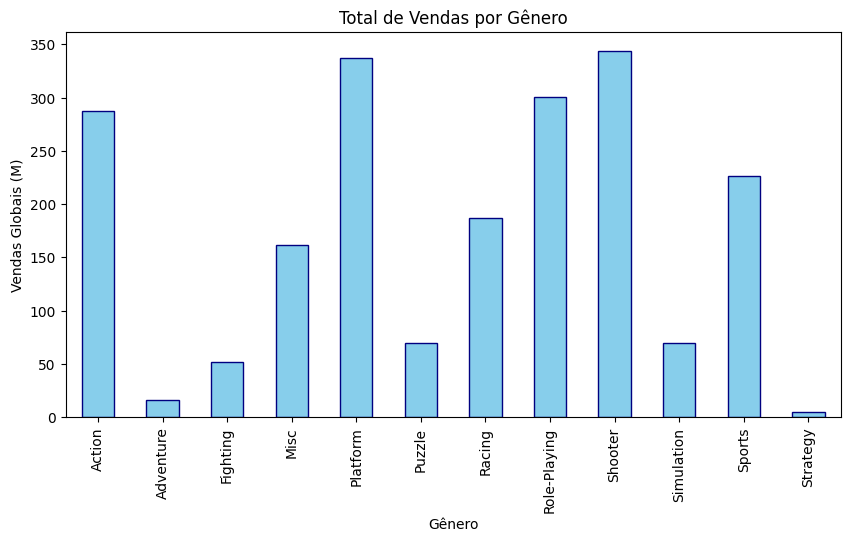

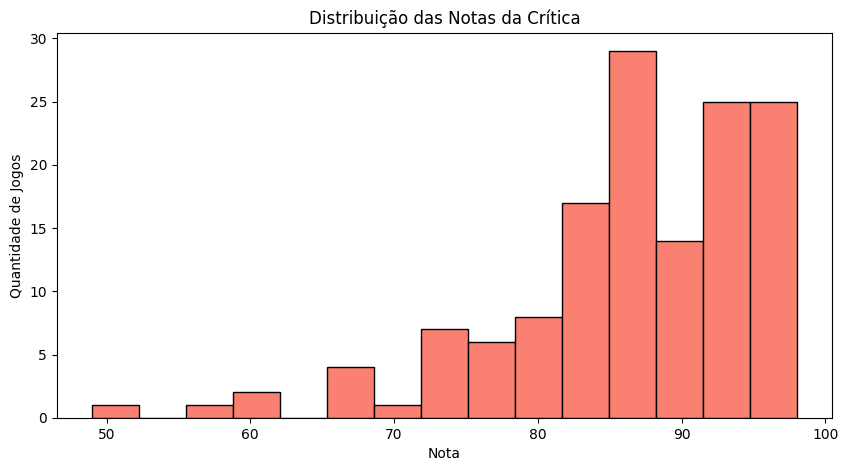

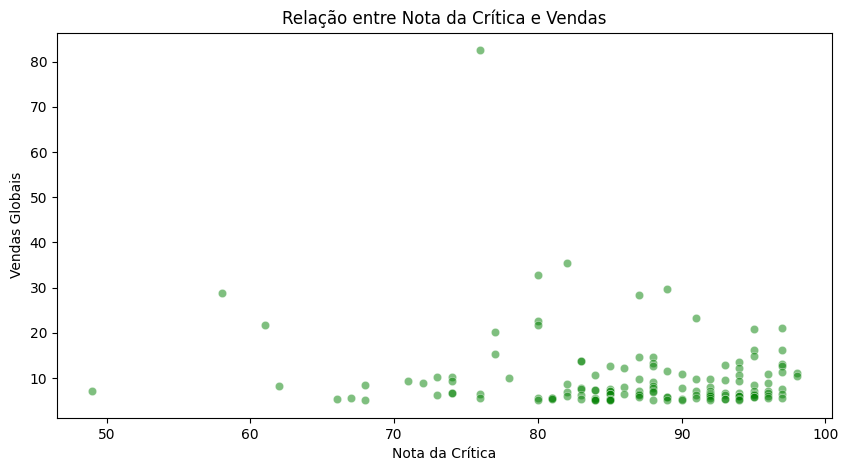

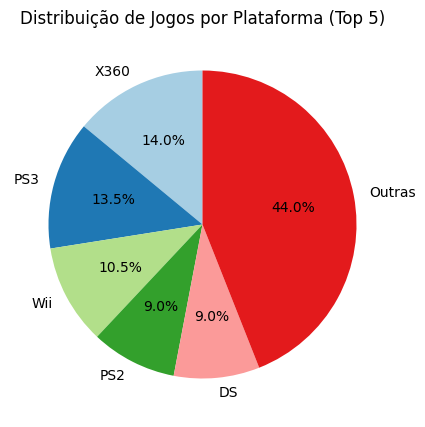

In [18]:
#melhorar os gráficos

# Gráfico 1: Barras (Vendas por Gênero)
plt.figure(figsize=(10, 5))
vendas_gen = df.groupby('Genre')['Global_Sales'].sum() #Para cada grupo de gênero, calcula a soma dos valores na coluna 'Global_Sales'. O resultado é uma *Series* onde o índice são os gêneros e os valores são as vendas totais.
vendas_gen.plot(kind='bar', color='skyblue', edgecolor='navy')
plt.title('Total de Vendas por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Vendas Globais (M)')
plt.savefig('grafico_barras.png') #salva a imagem em .png
plt.show() #mostra o gráfico
print('\n')

# Gráfico 2: Histograma (Distribuição das Notas)
plt.figure(figsize=(10, 5))
plt.hist(df['Critic_Score'].dropna(), bins=15, color='salmon', edgecolor='black')
plt.title('Distribuição das Notas da Crítica')
plt.xlabel('Nota')
plt.ylabel('Quantidade de Jogos')
plt.savefig('histograma_notas.png')
plt.show()
print('\n')

# Gráfico 3: Dispersão (Nota vs Vendas) - Usando Seaborn
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Critic_Score', y='Global_Sales', color='green', alpha=0.5)
plt.title('Relação entre Nota da Crítica e Vendas')
plt.xlabel('Nota da Crítica')
plt.ylabel('Vendas Globais')
plt.savefig('dispersao.png')
plt.show()
print('\n')

# Gráfico 4: Pizza/Setores (Porcentagem de jogos por plataforma)
# Conta quantos jogos tem de cada plataforma
plataformas_counts = df['Platform'].value_counts()

# Pega as top 5 plataformas e agrupa o restante como 'Outros'
top_5_plataformas = plataformas_counts.head(5)
outras_plataformas = pd.Series({'Outras': plataformas_counts.iloc[5:].sum()})

# Combina as top 5 com 'Outras'
data_pizza = pd.concat([top_5_plataformas, outras_plataformas])

plt.figure(figsize=(10, 5))
plt.pie(data_pizza, labels=data_pizza.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors) #labels = categorias startangle= começa do ângulo 90
plt.title('Distribuição de Jogos por Plataforma (Top 5)')
plt.savefig('grafico_pizza_plataforma.png')
plt.show()

BÔNUS

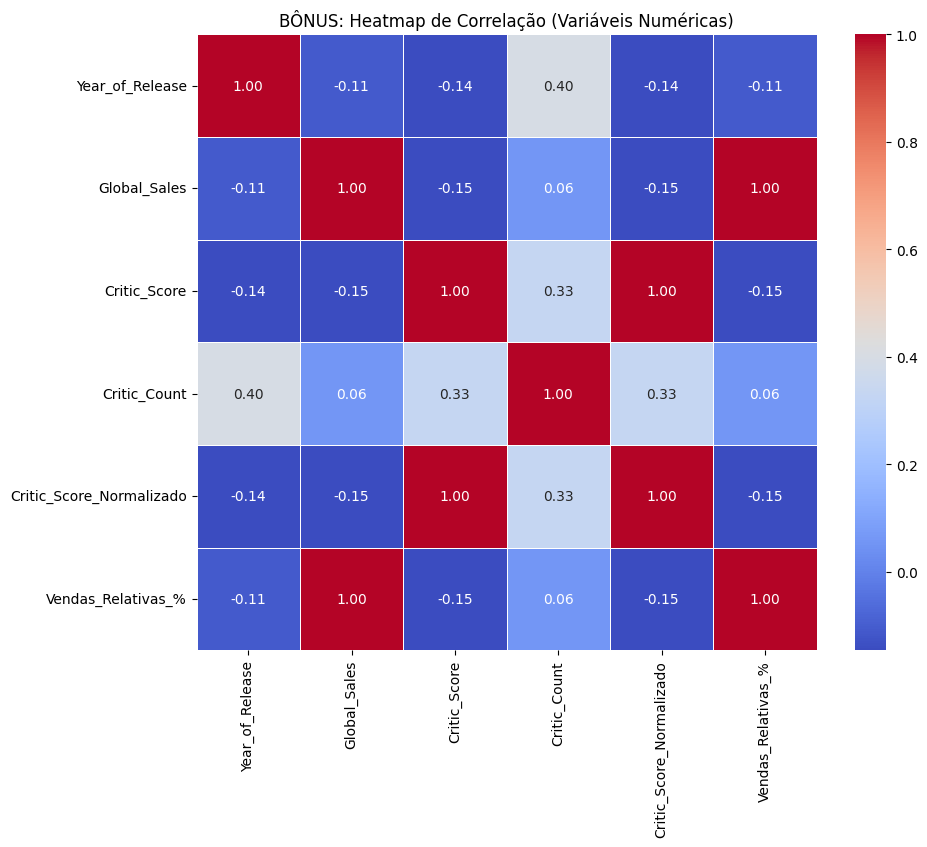

In [19]:
# 1. Seleção de Colunas Numéricas
# O Heatmap exige dados quantitativos. Filtramos apenas as colunas com números.
df_numerico = df.select_dtypes(include=[np.number]) #"Selecione todas as colunas que sejam de qualquer tipo numérico".

# 2. Cálculo da Matriz de Correlação
# O método .corr() calcula a relação entre as variáveis (-1 a 1).
'''
Próximo de 1 (Positiva Forte): As variáveis "sobem juntas". Se uma aumenta, a outra também aumenta (ex: quanto mais tempo de jogo, maior a pontuação).

Próximo de -1 (Negativa Forte): As variáveis são "inversamente proporcionais". Se uma sobe, a outra desce (ex: quanto mais pesado o jogo, menor o desempenho em FPS).

Próximo de 0 (Nula): Não existe uma relação linear clara. O movimento de uma não ajuda a prever o movimento da outra (ex: o ID do jogo não tem nada a ver com a nota da crítica).
'''
matriz_corr = df_numerico.corr()

# 3. Criação do Gráfico (Bônus)[cite: 3]
plt.figure(figsize=(10, 8))

# sns.heatmap: Gera o mapa de calor.
# annot=True: Coloca os valores dentro das células para facilitar a leitura.
# cmap='coolwarm': Escala de cor (vermelho para forte ligação positiva).
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Título descritivo conforme exigência[cite: 3]
plt.title('BÔNUS: Heatmap de Correlação (Variáveis Numéricas)')

# 4. Salvamento e Exibição[cite: 3]
plt.savefig('bonus_heatmap_exclusivo.png') # Salva em formato PNG[cite: 3]
plt.show()